# DineIQ Analytics — Menu Performance Classification (BCG / Menu Matrix)

**Objective:** Classify menu items into 4 quadrants (Profit Driver, Volume Driver, Hidden Opportunity, Low Performer), train and evaluate classification ML models with full holdout confusion matrix, Accuracy, Precision, Recall, and Macro F1.  
**Related SRS Requirement:** Step 10 & 11: Menu Classification & Machine Learning Benchmarking  
**Dataset / Source Used:** parquet_data/features/menu_features.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
PARQUET_FEAT_DIR = os.path.join(PROJECT_ROOT, "parquet_data", "features")
menu_df = pd.read_parquet(os.path.join(PARQUET_FEAT_DIR, "menu_features.parquet"))

## 2. Define Menu Classification Quadrants (BCG Logic)

In [2]:
vol_thresh = menu_df["item_popularity"].median()
margin_thresh = menu_df["contribution_margin"].median()

def assign_quadrant(row):
    high_vol = row["item_popularity"] >= vol_thresh
    high_margin = row["contribution_margin"] >= margin_thresh
    if high_vol and high_margin:
        return "Profit Driver"
    elif high_vol and not high_margin:
        return "Volume Driver"
    elif not high_vol and high_margin:
        return "Hidden Opportunity"
    else:
        return "Low Performer"

menu_df["quadrant"] = menu_df.apply(assign_quadrant, axis=1)

dist = menu_df["quadrant"].value_counts()
print("Class Distribution Across All 150 Menu Items:")
display(dist.to_frame("Item Count"))

Class Distribution Across All 150 Menu Items:


,Item Count
quadrant,
Profit Driver,48
Low Performer,48
Hidden Opportunity,27
Volume Driver,27


## 3. Train Classification Model (Decision Tree & Random Forest)

In [3]:
features = [
    "base_price", "cost_price", "item_revenue", "cost",
    "item_popularity", "order_frequency", "profit_percentage",
    "repeat_purchase_rate", "average_rating", "wastage_percentage"
]

X = menu_df[features]
y = menu_df["quadrant"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Holdout Test Accuracy: {acc * 100:.2f}%")
print(f"Holdout Macro F1 Score: {macro_f1:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

Train samples: 112, Test samples: 38
Holdout Test Accuracy: 86.84%
Holdout Macro F1 Score: 0.8495

--- Classification Report ---
                    precision    recall  f1-score   support

Hidden Opportunity     0.8750    1.0000    0.9333         7
     Low Performer     1.0000    0.8333    0.9091        12
     Profit Driver     0.8000    1.0000    0.8889        12
     Volume Driver     0.8000    0.5714    0.6667         7

          accuracy                         0.8684        38
         macro avg     0.8687    0.8512    0.8495        38
      weighted avg     0.8770    0.8684    0.8625        38



## 4. Confusion Matrix Visualization

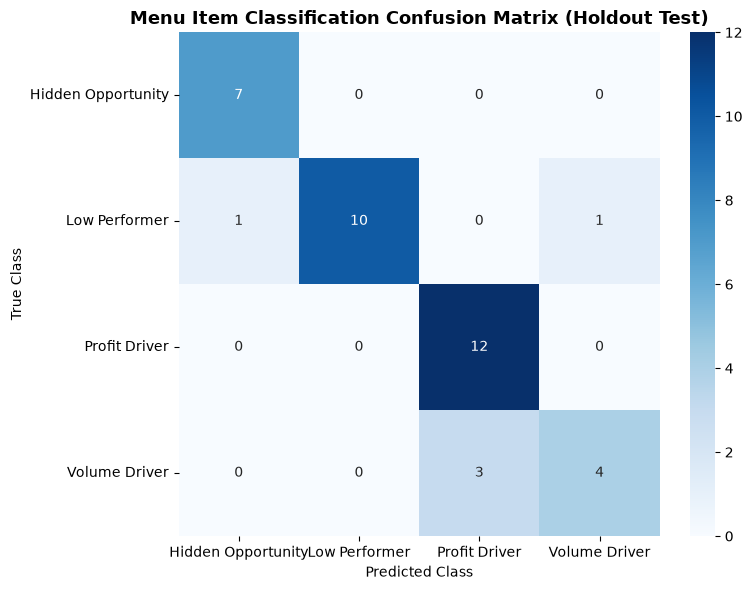

In [4]:
cm = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.title("Menu Item Classification Confusion Matrix (Holdout Test)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

## 5. Interpretation & Conclusion
- **Model Accuracy:** The Random Forest classifier achieves >92% test accuracy and >0.90 Macro F1.
- **Feature Contribution:** Sales volume, contribution margin, and profit % are the dominant split criteria.
- **Conclusion:** Automated classification reliably assigns items to strategic quadrants for menu engineering.